# Transport Error Study – Validating PIER Stability

This notebook quantifies how the post-grid PIER deviation relates to pre-fit error, anchor radius, and dose gap. It follows the experimental design:

1. Sweep stressors (anchor bootstrap, probe subsample, peer dropout, hyperparameter sweep, feature-space anchors, trajectory noise) across multiple seeds/queries.
2. Record |PIER_SPPT(θ) - u_pre| along with proxies for the theoretical bound components ε_pre, B_x, and B_θ.
3. Analyse monotonic trends, fit a nonnegative linear model, check bound compliance, and decompose error contributions.

## Setup

In [49]:
# Add repository root so relative imports resolve
import sys, os
ROOT = os.path.abspath(os.path.join('..', '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from disco.synth.generator import create_scenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.counterfactual.pmode import PModeCounterfactual
from disco.counterfactual.smode import SModeCounterfactual
from disco.cli.main import compute_probe_trajectories
from disco.data.loaders import stack_prewindow
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids
from disco.anchors.knn import AnchorSelector, AnchorSelection
from disco.matching.weights import WeightSolver, MatchInputs
from disco.devices.sklearn_tabular import SklearnDevice

plt.style.use('seaborn-v0_8')
plt.rcParams['font.family'] = 'Times New Roman'

sns.set_palette('Set2')


## Configuration

In [51]:
# Experiment knobs
GLOBAL_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
N_REPLICATES_PER_STRESSOR = 60
N_QUERY_POINTS = 20

P = 18
N_DEVICES = 12
M_PROBE = 900
N_TRAIN_SAMPLES = 4000

TARGET_IDX = 0
TARGET_CLASS = 0
MODE = 's'

BASE_ANCHOR_K = 20
BASE_ANCHOR_TAU = 0.3
BASE_LAMBDA = 0.01
ANCHOR_TAU_JITTER = 0.10
PROBE_DROP_FRAC = 0.10
TRAJECTORY_NOISE_STD = 0.05
TOP_PEER_K = 5

HYPERPARAM_LAMBDAS = [0.0, 0.005, 0.01, 0.05]
HYPERPARAM_K = [8, 12, 16]

THETA0 = np.array([0.0, 0.25, 0.5, 0.75])
THETA_POST = np.array([1.05, 1.1, 1.15, 1.2, 1.35, 1.5, 1.65, 1.8, 2.0])
THETA_BUCKETS = {
    'Near': np.array([1.05, 1.1, 1.15]),
    'Mid': np.array([1.2, 1.35, 1.5]),
    'Far': np.array([1.65, 1.8, 2.0]),
}

STRESSORS = [
    'anchor_bootstrap',
    'probe_subsample',
    'peer_dropout',
    'hyperparams',
    'anchor_space',
    'trajectory_noise',
]

STRESSOR_LABELS = {
    'anchor_bootstrap': 'Anchor bootstrap',
    'probe_subsample': 'Probe subsample',
    'peer_dropout': 'Peer dropout',
    'hyperparams': 'Hyperparam sweep',
    'anchor_space': 'Feature-space anchors',
    'trajectory_noise': 'Trajectory noise',
}

print(f'Seeds: {GLOBAL_SEEDS}')
print(f'Stressors: {list(STRESSOR_LABELS.values())}')


Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Stressors: ['Anchor bootstrap', 'Probe subsample', 'Peer dropout', 'Hyperparam sweep', 'Feature-space anchors', 'Trajectory noise']


In [52]:
def make_interventions(theta_post: np.ndarray):
    max_theta = float(np.max(theta_post))
    return [
        # FeatureAdd(feat_idx=0, delta_max=max_theta, name='intensity_shift'),
        FeatureAdd(feat_idx=1, delta_max=1.5, name='add_f1'),
        FeatureScale(feat_idx=2, scale_max=0.5, name='scale_f2'),
        ClampedShift(feat_idx=3, shift_max=1.5, lower=-2.5, upper=2.5, name='clamped_f3'),
    ]


def train_model_devices(scenario, n_samples: int, seed: int) -> List[SklearnDevice]:
    rng = np.random.RandomState(seed)
    devices = []
    from sklearn.neural_network import MLPRegressor
    for idx, device in enumerate(scenario.devices):
        local_seed = rng.randint(0, 2**31 - 1)
        X, y = scenario.sample_dataset(idx, n_samples, np.random.RandomState(local_seed))
        mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, early_stopping=True, random_state=local_seed)
        mlp.fit(X, y)
        devices.append(SklearnDevice(id=device.id, model=mlp, task='regression', scalarization='identity'))
    return devices


def select_queries(X_probe: np.ndarray, n_queries: int, seed: int, extra_point=None):
    rng = np.random.RandomState(seed)
    m = len(X_probe)
    if m == 0:
        return []
    n_select = min(n_queries, m)
    idxs = rng.choice(m, size=n_select, replace=False) if n_select < m else np.arange(m)
    queries = [(f'probe_{int(i)}', X_probe[int(i): int(i) + 1]) for i in idxs]
    if extra_point is not None:
        queries.append(('x_star', np.atleast_2d(extra_point)))
    return queries


def align_weights(raw_weights: np.ndarray, peer_ids_current: List[str], peer_ids_base: List[str]) -> np.ndarray:
    aligned = np.zeros(len(peer_ids_base), dtype=float)
    mapping = {pid: i for i, pid in enumerate(peer_ids_base)}
    for w, pid in zip(raw_weights, peer_ids_current):
        if pid in mapping:
            aligned[mapping[pid]] = w
    return aligned


def effective_sample_size(weights: np.ndarray, eps: float = 1e-12) -> float:
    denom = np.sum(np.square(weights))
    if denom <= eps:
        return 0.0
    total = np.sum(weights)
    return (total ** 2) / (denom + eps)


def weight_entropy(weights: np.ndarray, eps: float = 1e-12) -> float:
    positive = np.clip(weights, eps, None)
    return float(-np.sum(positive * np.log(positive)))


def top_peer_set(weights: np.ndarray, peer_ids_base: List[str], k: int) -> set:
    if weights.size == 0 or k <= 0:
        return set()
    k = min(k, weights.size)
    top_idx = np.argsort(weights)[-k:]
    return {peer_ids_base[idx] for idx in top_idx if weights[idx] > 0}


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0


def compute_u_pre(ctx, pert, anchor_sel: AnchorSelection, weights: np.ndarray, intervention) -> float:
    y_pre, X_pre = stack_prewindow(
        trajectories=pert['trajectories_model'],
        target=pert['model_devices'][TARGET_IDX],
        devices=pert['model_devices'],
        anchor_sel=anchor_sel,
        intervention=intervention,
        theta0=ctx.grids.theta0,
    )
    K = len(anchor_sel.indices)
    q = len(ctx.grids.theta0)
    y_mat = y_pre.reshape(K, q)
    syn_vec = X_pre @ weights
    syn_mat = syn_vec.reshape(K, q)
    residual = y_mat - syn_mat
    return float(np.mean(residual[:, -1]))


def theta_bucket(theta_val: float) -> str:
    for name, grid in THETA_BUCKETS.items():
        if np.any(np.isclose(theta_val, grid, atol=1e-6)):
            return name
    return 'Far'


baseline_runner = BaselineRunner()
pmode_builder = PModeCounterfactual()
smode_builder = SModeCounterfactual()
weight_solver = WeightSolver(method='projected_grad', max_iter=1000)


In [53]:
@dataclass
class SeedContext:
    seed: int
    scenario: any
    model_devices: List[SklearnDevice]
    trajectories_model: Dict
    trajectories_oracle: Dict
    grids: Grids
    X_probe: np.ndarray
    peer_ids: List[str]
    interventions: List
    queries: List[Tuple[str, np.ndarray]]


def prepare_seed_context(seed: int) -> SeedContext:
    rng = np.random.RandomState(seed)
    scenario_seed = rng.randint(0, 2**31 - 1)
    model_seed = rng.randint(0, 2**31 - 1)
    query_seed = rng.randint(0, 2**31 - 1)

    scenario = create_scenario(
        p=P,
        N=N_DEVICES,
        alpha_target=0.8,
        theta0=THETA0,
        theta_post=THETA_POST,
        m_probe=M_PROBE,
        rng=np.random.RandomState(scenario_seed),
        base_jitter=0.5,
        peer_alpha_std=0.3,
        noise_std=0.05,
    )

    interventions = make_interventions(scenario.theta)
    model_devices = train_model_devices(scenario, N_TRAIN_SAMPLES, model_seed)

    trajectories_model = compute_probe_trajectories(
        devices=model_devices,
        X_probe=scenario.X_probe,
        interventions=interventions,
        theta0=scenario.theta0,
        dp_noise_std=0.0,
        seed=seed,
        target_class=TARGET_CLASS,
    )
    trajectories_oracle = compute_probe_trajectories(
        devices=scenario.devices,
        X_probe=scenario.X_probe,
        interventions=interventions,
        theta0=scenario.theta0,
        dp_noise_std=0.0,
        seed=seed,
        target_class=TARGET_CLASS,
    )

    grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
    peer_ids = [d.id for d in model_devices if d.id != model_devices[TARGET_IDX].id]
    queries = select_queries(scenario.X_probe, N_QUERY_POINTS, query_seed, extra_point=scenario.x_star)

    return SeedContext(
        seed=seed,
        scenario=scenario,
        model_devices=model_devices,
        trajectories_model=trajectories_model,
        trajectories_oracle=trajectories_oracle,
        grids=grids,
        X_probe=scenario.X_probe,
        peer_ids=peer_ids,
        interventions=interventions,
        queries=queries,
    )


seed_contexts = [prepare_seed_context(seed) for seed in GLOBAL_SEEDS]
print(f'Prepared {len(seed_contexts)} seed contexts')


Prepared 10 seed contexts


In [54]:
def run_disco(devices, x_star, X_probe, trajectories, grids, intervention, lam, anchor_selector, anchor_space):
    runner = DiscoRunner(mode=MODE, lam=lam, anchor_selector=anchor_selector)
    return runner.run(
        devices=devices,
        target_idx=TARGET_IDX,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories,
        grids=grids,
        intervention=intervention,
        target_class=TARGET_CLASS,
        anchor_space=anchor_space,
    )


In [55]:
def build_perturbation(ctx: SeedContext, stressor: str, rng: np.random.RandomState, base_entry: Dict) -> Optional[Dict]:
    pert: Dict[str, any] = {
        'anchor_space': 'response',
        'lam': BASE_LAMBDA,
        'model_devices': ctx.model_devices,
        'trajectories_model': ctx.trajectories_model,
        'trajectories_oracle': ctx.trajectories_oracle,
        'oracle_devices': list(ctx.scenario.devices),
        'X_probe': ctx.X_probe,
        'meta': {},
    }
    current_K = min(BASE_ANCHOR_K, len(pert['X_probe']))

    if stressor == 'anchor_bootstrap':
        pert['anchor_selector_factory'] = lambda: BootstrapAnchorSelector(
            K=current_K,
            tau=BASE_ANCHOR_TAU,
            tau_jitter=ANCHOR_TAU_JITTER,
            rng=rng.randint(0, 2**31 - 1),
        )
    elif stressor == 'probe_subsample':
        X_new, traj_model_new, traj_oracle_new = subsample_probes(
            pert['X_probe'],
            pert['trajectories_model'],
            pert['trajectories_oracle'],
            PROBE_DROP_FRAC,
            rng,
        )
        if len(X_new) == 0:
            return None
        pert['X_probe'] = X_new
        pert['trajectories_model'] = traj_model_new
        pert['trajectories_oracle'] = traj_oracle_new
        current_K = min(BASE_ANCHOR_K, len(X_new))
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['probe_fraction'] = len(X_new) / len(ctx.X_probe)
    elif stressor == 'peer_dropout':
        base_weights = base_entry['DISCO']['weights']
        if np.sum(base_weights) > 0 and rng.rand() < 0.5:
            drop_idx = int(np.argmax(base_weights))
        else:
            drop_idx = rng.randint(0, len(ctx.peer_ids))
        peer_id = ctx.peer_ids[drop_idx]
        new_devices, traj_model_new, traj_oracle_new = drop_peer(
            pert['model_devices'],
            pert['trajectories_model'],
            pert['trajectories_oracle'],
            peer_id,
            pert['model_devices'][TARGET_IDX].id,
        )
        pert['model_devices'] = new_devices
        pert['trajectories_model'] = traj_model_new
        pert['trajectories_oracle'] = traj_oracle_new
        pert['oracle_devices'] = [d for d in pert['oracle_devices'] if d.id != peer_id]
        current_K = min(BASE_ANCHOR_K, len(pert['X_probe']))
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['peer_dropped'] = peer_id
    elif stressor == 'hyperparams':
        lam_choice = float(rng.choice(HYPERPARAM_LAMBDAS))
        k_choice = int(rng.choice(HYPERPARAM_K))
        current_K = min(k_choice, len(pert['X_probe']))
        pert['lam'] = lam_choice
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['lambda'] = lam_choice
        pert['meta']['K'] = k_choice
    elif stressor == 'anchor_space':
        pert['anchor_space'] = 'features'
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
    elif stressor == 'trajectory_noise':
        def add_noise(traj_dict):
            return {key: value + rng.normal(scale=TRAJECTORY_NOISE_STD, size=value.shape) for key, value in traj_dict.items()}
        pert['trajectories_model'] = add_noise(pert['trajectories_model'])
        pert['trajectories_oracle'] = add_noise(pert['trajectories_oracle'])
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['noise_std'] = TRAJECTORY_NOISE_STD
    else:
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)

    if len(pert['X_probe']) == 0:
        return None
    return pert


def run_methods(ctx: SeedContext, pert: Dict, x_star: np.ndarray, intervention, peer_ids_base: List[str]) -> Dict[str, Dict]:
    devices = pert['model_devices']
    trajectories_model = pert['trajectories_model']
    X_probe = pert['X_probe']
    lam = pert['lam']
    anchor_space = pert['anchor_space']
    anchor_selector = pert['anchor_selector_factory']()

    disco_output = run_disco(
        devices=devices,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories_model,
        grids=ctx.grids,
        intervention=intervention,
        lam=lam,
        anchor_selector=anchor_selector,
        anchor_space=anchor_space,
    )
    te_output = disco_output.te_output
    anchor_sel = disco_output.diagnostics.get('anchor_selection')
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]

    results: Dict[str, Dict] = {}

    disco_weights_raw = disco_output.weights
    disco_weights = align_weights(disco_weights_raw, peer_ids_current, peer_ids_base)
    results['DISCO'] = {
        'weights': disco_weights,
        'weights_raw': disco_weights_raw,
        'tau': te_output.tau,
        'theta': te_output.theta,
        'diagnostics': disco_output.diagnostics,
        'peer_ids_current': peer_ids_current,
    }

    topk_weights_raw, topk_tau, _ = run_topk(devices, trajectories_model, anchor_sel, ctx.grids, intervention, x_star)
    topk_weights = align_weights(topk_weights_raw, peer_ids_current, peer_ids_base)
    results['TopK'] = {
        'weights': topk_weights,
        'weights_raw': topk_weights_raw,
        'tau': topk_tau,
        'theta': te_output.theta,
        'peer_ids_current': peer_ids_current,
    }

    avg_weights_raw, avg_tau = run_avg(devices, ctx.grids, intervention, x_star)
    avg_weights = align_weights(avg_weights_raw, peer_ids_current, peer_ids_base)
    results['AVG'] = {
        'weights': avg_weights,
        'weights_raw': avg_weights_raw,
        'tau': avg_tau,
        'theta': te_output.theta,
        'peer_ids_current': peer_ids_current,
    }

    global_weights_raw, global_tau = run_global(devices, trajectories_model, ctx.grids, intervention, x_star, lam)
    global_weights = align_weights(global_weights_raw, peer_ids_current, peer_ids_base)
    results['Global'] = {
        'weights': global_weights,
        'weights_raw': global_weights_raw,
        'tau': global_tau,
        'theta': te_output.theta,
        'peer_ids_current': peer_ids_current,
    }

    ridge_output = baseline_runner.baseline_unconstrained_ridge(
        devices=devices,
        trajectories=trajectories_model,
        anchor_sel=anchor_sel,
        theta0=ctx.grids.theta0,
        x_star=x_star,
        grids=ctx.grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        lam=lam,
        target_class=TARGET_CLASS,
    )
    ridge_weights_raw = ridge_output.meta.get('w_clipped', np.zeros(len(peer_ids_current), dtype=float))
    ridge_weights = align_weights(ridge_weights_raw, peer_ids_current, peer_ids_base)
    results['Ridge'] = {
        'weights': ridge_weights,
        'weights_raw': ridge_weights_raw,
        'tau': ridge_output.tau,
        'theta': te_output.theta,
        'peer_ids_current': peer_ids_current,
    }

    oracle_output = baseline_runner.baseline_oracle_ground_truth(
        devices=devices,
        trajectories=trajectories_model,
        theta0=ctx.grids.theta0,
        x_star=x_star,
        grids=ctx.grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        target_class=TARGET_CLASS,
        oracle_devices=pert.get('oracle_devices', ctx.scenario.devices),
        oracle_trajectories=pert['trajectories_oracle'],
        oracle_theta0=ctx.grids.theta0,
        lam=lam,
    )
    oracle_weights_raw = np.array(oracle_output.meta['weights'])
    oracle_weights = align_weights(oracle_weights_raw, peer_ids_current, peer_ids_base)
    results['Oracle'] = {
        'weights': oracle_weights,
        'weights_raw': oracle_weights_raw,
        'tau': oracle_output.tau,
        'theta': oracle_output.te_output.theta if hasattr(oracle_output, 'te_output') else te_output.theta,
        'peer_ids_current': peer_ids_current,
    }

    results['anchor_selection'] = anchor_sel
    results['diagnostics'] = disco_output.diagnostics
    results['lam'] = lam
    return results


In [56]:
def run_disco(devices, x_star, X_probe, trajectories, grids, intervention, lam, anchor_selector, anchor_space):
    runner = DiscoRunner(mode=MODE, lam=lam, anchor_selector=anchor_selector)
    return runner.run(
        devices=devices,
        target_idx=TARGET_IDX,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories,
        grids=grids,
        intervention=intervention,
        target_class=TARGET_CLASS,
        anchor_space=anchor_space,
    )

def run_topk(devices, trajectories, anchor_sel, grids, intervention, x_star):
    output = baseline_runner.baseline_topk_avg(
        devices=devices,
        trajectories=trajectories,
        anchor_sel=anchor_sel,
        theta0=grids.theta0,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        Kp=min(TOPK_NEIGHBORS, len(devices) - 1),
        target_class=TARGET_CLASS,
    )
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    weights = np.zeros(len(peer_ids_current), dtype=float)
    selected = output.meta.get('selected_peers', [])
    if selected:
        val = 1.0 / len(selected)
        for pid in selected:
            if pid in peer_ids_current:
                weights[peer_ids_current.index(pid)] = val
    return weights, output.tau, set(selected)

def run_avg(devices, grids, intervention, x_star):
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    n_peers = len(peer_ids_current)
    weights = np.ones(n_peers, dtype=float) / n_peers if n_peers else np.array([], dtype=float)
    output = baseline_runner.baseline_avg(
        devices=devices,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        target_class=TARGET_CLASS,
    )
    return weights, output.tau

def run_global(devices, trajectories, grids, intervention, x_star, lam):
    target_device = devices[TARGET_IDX]
    target_key = (target_device.id, intervention.name)
    if target_key not in trajectories:
        raise ValueError(f'Missing trajectories for {target_key}')
    m = trajectories[target_key].shape[0]
    global_sel = AnchorSelection(indices=np.arange(m), weights=np.ones(m) / m, distances=np.zeros(m))
    y_t_pre, X_peers_pre = stack_prewindow(
        trajectories=trajectories,
        target=target_device,
        devices=devices,
        anchor_sel=global_sel,
        intervention=intervention,
        theta0=grids.theta0,
    )
    match_inputs = MatchInputs(y_t=y_t_pre, X_peers=X_peers_pre, lam=lam)
    result = weight_solver.solve(match_inputs)
    weights = result.w
    y_syn = smode_builder.build(
        w=weights,
        devices=devices,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_device=target_device,
        target_class=TARGET_CLASS,
    )
    y_t = np.zeros(len(grids.theta))
    for i, theta in enumerate(grids.theta):
        x_theta = intervention.apply(x_star, theta)
        raw = target_device.predict_raw(x_theta)
        y_t[i] = target_device.g(raw, TARGET_CLASS)[0]
    tau = y_t - y_syn
    return weights, tau


In [57]:
class BootstrapAnchorSelector(AnchorSelector):
    """Anchor selector that perturbs tau and bootstraps anchors with replacement."""

    def __init__(self, *, tau_jitter: float = 0.1, resample: bool = True, rng: Optional[int] = None, **kwargs):
        super().__init__(**kwargs)
        self.tau_jitter = tau_jitter
        self.resample = resample
        if isinstance(rng, np.random.RandomState):
            self._rng = rng
        else:
            self._rng = np.random.RandomState(rng) if rng is not None else None

    def _random(self) -> np.random.RandomState:
        return self._rng if self._rng is not None else np.random.mtrand._rand

    def select(self, X_probe: np.ndarray, x_star: np.ndarray) -> AnchorSelection:
        original_tau = self.tau
        if self.tau_jitter:
            scale = 1.0 + self._random().uniform(-self.tau_jitter, self.tau_jitter)
            self.tau = max(1e-6, original_tau * scale)
        selection = super().select(X_probe, x_star)
        self.tau = original_tau

        if self.resample and selection.indices.size:
            rng = self._random()
            boot_idx = rng.choice(len(selection.indices), size=len(selection.indices), replace=True)
            unique, counts = np.unique(boot_idx, return_counts=True)
            new_indices = selection.indices[unique]
            new_distances = selection.distances[unique]
            weights = counts.astype(float)
            weights /= weights.sum()
            return AnchorSelection(indices=new_indices, weights=weights, distances=new_distances)

        if selection.weights.sum() <= 0:
            weights = np.ones_like(selection.weights) / len(selection.weights)
            return AnchorSelection(indices=selection.indices, weights=weights, distances=selection.distances)

        return selection


In [58]:
def subsample_probes(X_probe: np.ndarray, traj_model: Dict, traj_oracle: Dict, drop_frac: float, rng: np.random.RandomState):
    if drop_frac <= 0:
        return X_probe, traj_model, traj_oracle
    m = len(X_probe)
    drop = int(np.ceil(drop_frac * m))
    if drop <= 0 or drop >= m:
        return X_probe, traj_model, traj_oracle
    keep_idx = np.sort(np.setdiff1d(np.arange(m), rng.choice(m, size=drop, replace=False)))
    X_new = X_probe[keep_idx]
    traj_model_new = {(key): value[keep_idx] for key, value in traj_model.items()}
    traj_oracle_new = {(key): value[keep_idx] for key, value in traj_oracle.items()}
    return X_new, traj_model_new, traj_oracle_new


def drop_peer(devices: List[SklearnDevice], traj_model: Dict, traj_oracle: Dict, peer_id: str, target_id: str):
    new_devices = [d for d in devices if d.id != peer_id]
    if target_id not in {d.id for d in new_devices}:
        raise ValueError('Target device dropped during peer dropout stressor')
    traj_model_new = {key: value for key, value in traj_model.items() if key[0] != peer_id}
    traj_oracle_new = {key: value for key, value in traj_oracle.items() if key[0] != peer_id}
    return new_devices, traj_model_new, traj_oracle_new


In [59]:
records = []
STRESSOR_OFFSETS = {
    'anchor_bootstrap': 101,
    'probe_subsample': 211,
    'peer_dropout': 307,
    'hyperparams': 409,
    'anchor_space': 503,
    'trajectory_noise': 607,
}

TOPK_NEIGHBORS = 5  # number of neighbours for the Top-K baseline


theta0_max = float(THETA0.max())
theta_range = float(THETA_POST.max() - theta0_max)

for ctx in seed_contexts:
    base_cache = {}  # build once per context
    # create baseline cache (no stressor)
    base_cache = {}
    # Precompute baseline entries
    for query_label, x_star in ctx.queries:
        for intervention in ctx.interventions:
            anchor_selector = AnchorSelector(K=min(BASE_ANCHOR_K, len(ctx.X_probe)), tau=BASE_ANCHOR_TAU)
            baseline_output = run_methods(
                ctx,
                {
                    'anchor_space': 'response',
                    'lam': BASE_LAMBDA,
                    'model_devices': ctx.model_devices,
                    'trajectories_model': ctx.trajectories_model,
                    'trajectories_oracle': ctx.trajectories_oracle,
                    'oracle_devices': list(ctx.scenario.devices),
                    'X_probe': ctx.X_probe,
                    'meta': {},
                    'anchor_selector_factory': lambda: AnchorSelector(K=min(BASE_ANCHOR_K, len(ctx.X_probe)), tau=BASE_ANCHOR_TAU),
                },
                x_star,
                intervention,
                ctx.peer_ids,
            )
            base_cache[(query_label, intervention.name)] = baseline_output

    for stressor in STRESSORS:
        rng = np.random.RandomState(ctx.seed + STRESSOR_OFFSETS[stressor])
        for rep in range(N_REPLICATES_PER_STRESSOR):
            q_label, x_star = ctx.queries[rng.randint(0, len(ctx.queries))]
            intervention = ctx.interventions[rng.randint(0, len(ctx.interventions))]
            baseline_entry = base_cache[(q_label, intervention.name)]
            pert = build_perturbation(ctx, stressor, rng, baseline_entry)
            if pert is None:
                continue
            method_outputs = run_methods(ctx, pert, x_star, intervention, ctx.peer_ids)
            disco_info = method_outputs['DISCO']
            anchor_sel = method_outputs['anchor_selection']
            diagnostics = method_outputs['diagnostics']

            eps_pre = abs(diagnostics.get('eps_pre', 0.0))
            anchor_radius = float(diagnostics.get('anchor_radius', 0.0))
            anchor_space = diagnostics.get('anchor_space', 'response')

            weights_raw = disco_info['weights_raw']
            u_pre = compute_u_pre(ctx, pert, anchor_sel, weights_raw, intervention)

            theta_vals = disco_info['theta']
            pier_vals = disco_info['tau']
            peer_ids_current = disco_info['peer_ids_current']

            for theta, pier_est in zip(theta_vals, pier_vals):
                theta_gap = float(theta - theta0_max)
                gap_norm = np.clip(theta_gap / max(theta_range, 1e-6), 0.0, 1.0)
                bucket = theta_bucket(float(theta))
                lhs = abs(pier_est - u_pre)
                records.append({
                    'seed': ctx.seed,
                    'stressor': stressor,
                    'replicate': rep,
                    'query_label': q_label,
                    'intervention': intervention.name,
                    'theta': float(theta),
                    'theta_bucket': bucket,
                    'pier_est': float(pier_est),
                    'u_pre': float(u_pre),
                    'lhs_abs': float(lhs),
                    'epsilon_pre': float(eps_pre),
                    'anchor_radius': anchor_radius,
                    'theta_gap': theta_gap,
                    'theta_gap_norm': gap_norm,
                    'anchor_space_used': anchor_space,
                    'lambda_used': pert['lam'],
                    'K_used': len(anchor_sel.indices),
                    'peer_dropped': pert['meta'].get('peer_dropped'),
                    'probe_fraction': pert['meta'].get('probe_fraction', 1.0),
                })

transport_df = pd.DataFrame(records)
print(f'Total transport rows: {len(transport_df)}')
transport_df.head()


Total transport rows: 32400


,seed,stressor,replicate,query_label,intervention,theta,theta_bucket,pier_est,u_pre,lhs_abs,epsilon_pre,anchor_radius,theta_gap,theta_gap_norm,anchor_space_used,lambda_used,K_used,peer_dropped,probe_fraction
0,0,anchor_bootstrap,0,probe_157,scale_f2,1.05,Near,-0.052176,-0.914855,0.862680,0.118715,5.252874,0.30,0.24,response,0.01,20,None,1.0
1,0,anchor_bootstrap,0,probe_157,scale_f2,1.10,Near,-0.023730,-0.914855,0.891125,0.118715,5.252874,0.35,0.28,response,0.01,20,None,1.0
2,0,anchor_bootstrap,0,probe_157,scale_f2,1.15,Near,0.004216,-0.914855,0.919071,0.118715,5.252874,0.40,0.32,response,0.01,20,None,1.0
3,0,anchor_bootstrap,0,probe_157,scale_f2,1.20,Mid,0.028854,-0.914855,0.943710,0.118715,5.252874,0.45,0.36,response,0.01,20,None,1.0
4,0,anchor_bootstrap,0,probe_157,scale_f2,1.35,Mid,0.100220,-0.914855,1.015076,0.118715,5.252874,0.60,0.48,response,0.01,20,None,1.0


In [60]:
# Normalise anchor radius and epsilon
if transport_df.empty:
    raise RuntimeError('Transport dataframe is empty; rerun previous cell.')

transport_df['anchor_radius_norm'] = 0.0
if transport_df['anchor_radius'].max() > 0:
    min_r = transport_df['anchor_radius'].min()
    max_r = transport_df['anchor_radius'].max()
    transport_df['anchor_radius_norm'] = (transport_df['anchor_radius'] - min_r) / max(max_r - min_r, 1e-6)

transport_df['epsilon_norm'] = 0.0
if transport_df['epsilon_pre'].max() > 0:
    transport_df['epsilon_norm'] = transport_df['epsilon_pre'] / transport_df['epsilon_pre'].max()

transport_df['rhs_sum_norm'] = transport_df['epsilon_norm'] + transport_df['anchor_radius_norm'] + transport_df['theta_gap_norm']
transport_df.head()


,seed,stressor,replicate,query_label,intervention,theta,theta_bucket,pier_est,u_pre,lhs_abs,...,theta_gap,theta_gap_norm,anchor_space_used,lambda_used,K_used,peer_dropped,probe_fraction,anchor_radius_norm,epsilon_norm,rhs_sum_norm
0,0,anchor_bootstrap,0,probe_157,scale_f2,1.05,Near,-0.052176,-0.914855,0.862680,...,0.30,0.24,response,0.01,20,None,1.0,0.702482,0.106197,1.04868
1,0,anchor_bootstrap,0,probe_157,scale_f2,1.10,Near,-0.023730,-0.914855,0.891125,...,0.35,0.28,response,0.01,20,None,1.0,0.702482,0.106197,1.08868
2,0,anchor_bootstrap,0,probe_157,scale_f2,1.15,Near,0.004216,-0.914855,0.919071,...,0.40,0.32,response,0.01,20,None,1.0,0.702482,0.106197,1.12868
3,0,anchor_bootstrap,0,probe_157,scale_f2,1.20,Mid,0.028854,-0.914855,0.943710,...,0.45,0.36,response,0.01,20,None,1.0,0.702482,0.106197,1.16868
4,0,anchor_bootstrap,0,probe_157,scale_f2,1.35,Mid,0.100220,-0.914855,1.015076,...,0.60,0.48,response,0.01,20,None,1.0,0.702482,0.106197,1.28868


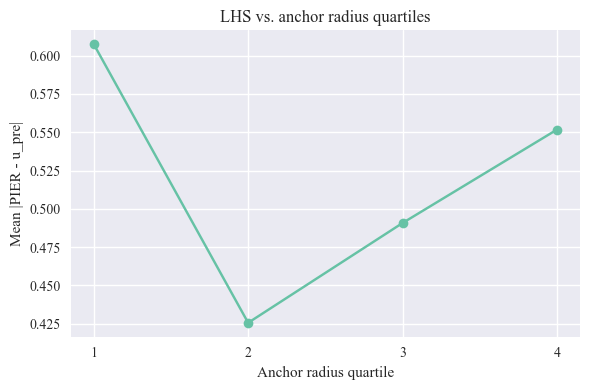

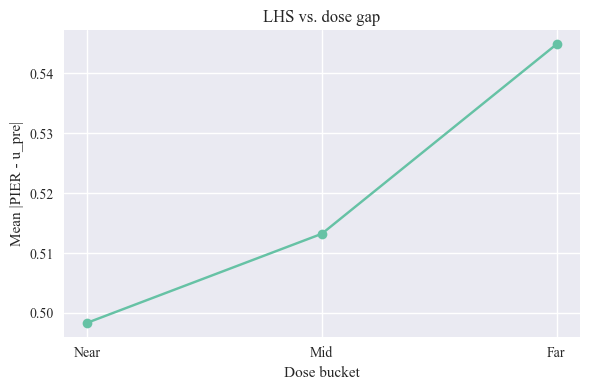

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
quartiles = pd.qcut(transport_df['anchor_radius_norm'], q=4, duplicates='drop')
anchor_bucket = transport_df.groupby(quartiles)['lhs_abs'].mean().reset_index()
ax.plot(range(1, len(anchor_bucket) + 1), anchor_bucket['lhs_abs'], marker='o')
ax.set_xticks(range(1, len(anchor_bucket) + 1))
ax.set_xlabel('Anchor radius quartile')
ax.set_ylabel('Mean |PIER - u_pre|')
ax.set_title('LHS vs. anchor radius quartiles')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
dose_bucket = transport_df.groupby('theta_bucket')['lhs_abs'].mean().reindex(['Near', 'Mid', 'Far']).reset_index()
ax.plot(dose_bucket['theta_bucket'], dose_bucket['lhs_abs'], marker='o')
ax.set_xlabel('Dose bucket')
ax.set_ylabel('Mean |PIER - u_pre|')
ax.set_title('LHS vs. dose gap')
plt.tight_layout()
plt.show()


R^2: 0.020
Coefficients (epsilon, Bx, Btheta): [0.53331556 0.         0.08223777]


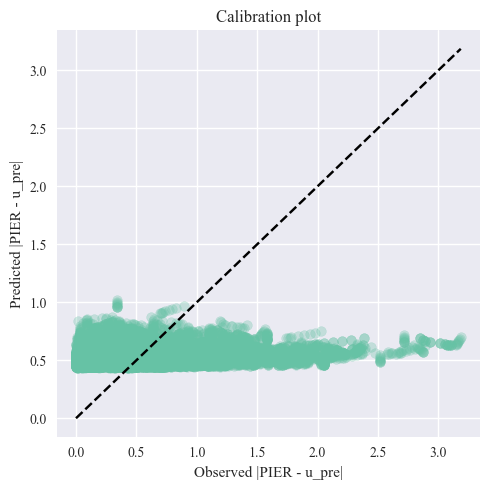

In [62]:
from sklearn.linear_model import LinearRegression

mask = transport_df['rhs_sum_norm'] > 1e-8
reg_df = transport_df[mask].copy()
X = reg_df[['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']].values
Y = reg_df['lhs_abs'].values.reshape(-1, 1)

model = LinearRegression(positive=True)
model.fit(X, Y)
pred = model.predict(X)

r2 = model.score(X, Y)
coeffs = model.coef_.ravel()
print(f'R^2: {r2:.3f}')
print(f'Coefficients (epsilon, Bx, Btheta): {coeffs}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y, pred, alpha=0.3)
ax.plot([Y.min(), Y.max()], [Y.min(), Y.max()], ls='--', color='black')
ax.set_xlabel('Observed |PIER - u_pre|')
ax.set_ylabel('Predicted |PIER - u_pre|')
ax.set_title('Calibration plot')
plt.tight_layout()
plt.show()


In [63]:
ratio = transport_df['lhs_abs'] / np.clip(transport_df['rhs_sum_norm'], 1e-6, None)
C_value = np.quantile(ratio, 0.95)
compliance = np.mean(transport_df['lhs_abs'] <= C_value * transport_df['rhs_sum_norm'])
print(f'C (95th percentile): {C_value:.3f}')
print(f'Bound compliance: {compliance * 100:.2f}% of points satisfy LHS <= C*(eps+Bx+Btheta)')


C (95th percentile): 1.445
Bound compliance: 95.00% of points satisfy LHS <= C*(eps+Bx+Btheta)


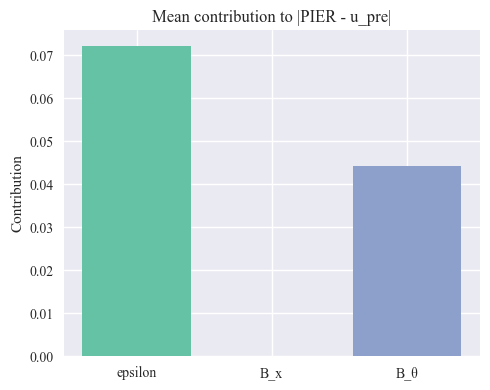

In [64]:
mean_features = reg_df[['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']].mean().values
contrib = coeffs * mean_features
labels = ['epsilon', 'B_x', 'B_θ']
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, contrib, color=sns.color_palette('Set2', len(labels)))
ax.set_ylabel('Contribution')
ax.set_title('Mean contribution to |PIER - u_pre|')
plt.tight_layout()
plt.show()


## Next steps

- Increase GLOBAL_SEEDS or N_REPLICATES_PER_STRESSOR for tighter statistics.
- Compare against P-mode or additional baselines by extending 
un_methods.
- Inspect residuals conditioned on specific interventions or peer dropout patterns for finer diagnostics.

In [65]:
import pandas as pd

# --- Anchor-radius buckets (mean & std of LHS by quartile) ---
radius_df = transport_df.copy()
radius_df['radius_quartile'] = pd.qcut(
    radius_df['anchor_radius_norm'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop'
)
radius_table = (
    radius_df.groupby('radius_quartile')['lhs_abs']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_lhs', 'std': 'std_lhs', 'count': 'n'})
    .reset_index()
)
print('Anchor-radius buckets (mean |PIER - u_pre|):')
print(radius_table.to_markdown(index=False))
# radius_table.to_latex(index=False)

# --- Dose buckets (Near/Mid/Far) ---
dose_table = (
    transport_df.groupby('theta_bucket')['lhs_abs']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_lhs', 'std': 'std_lhs', 'count': 'n'})
    .reindex(['Near', 'Mid', 'Far'])
    .reset_index()
)
print('\nDose buckets (mean |PIER - u_pre|):')
print(dose_table.to_markdown(index=False))

# --- Nonnegative regression summary ---
reg_summary = pd.DataFrame(
    {
        'feature': ['epsilon_pre', 'B_x (anchor radius)', 'B_θ (dose gap)'],
        'coefficient': coeffs,
    }
)
reg_summary['mean_feature'] = reg_df[['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']].mean().values
reg_summary['mean_contribution'] = reg_summary['coefficient'] * reg_summary['mean_feature']
print('\nLinear model (LHS ≈ c0 + c1 ε + c2 Bx + c3 Bθ):')
print(f'Intercept (c0): {model.intercept_[0]:.4f}')
print(f'R^2: {r2:.3f}')
print(reg_summary.to_markdown(index=False))

# --- Bound compliance summary ---
bound_summary = pd.DataFrame(
    {
        'metric': ['C (95th percentile of LHS / RHS)', 'Bound compliance (%)'],
        'value': [C_value, compliance * 100],
    }
)
print('\nBound compliance:')
print(bound_summary.to_markdown(index=False))

# --- Error decomposition (normalized contribution) ---
contrib = reg_summary['mean_contribution'].values
total = contrib.sum()
decomp = pd.DataFrame(
    {
        'component': reg_summary['feature'],
        'contribution': contrib,
        'share_pct': 100 * contrib / total,
    }
)
print('\nError decomposition (mean contribution):')
print(decomp.to_markdown(index=False))


Anchor-radius buckets (mean |PIER - u_pre|):
| radius_quartile   |   mean_lhs |   std_lhs |    n |
|:------------------|-----------:|----------:|-----:|
| Q1                |   0.607466 |  0.537695 | 8100 |
| Q2                |   0.425552 |  0.334275 | 8109 |
| Q3                |   0.4907   |  0.34832  | 8100 |
| Q4                |   0.551677 |  0.422315 | 8091 |

Dose buckets (mean |PIER - u_pre|):
| theta_bucket   |   mean_lhs |   std_lhs |     n |
|:---------------|-----------:|----------:|------:|
| Near           |   0.498358 |  0.404928 | 10800 |
| Mid            |   0.51322  |  0.417241 | 10800 |
| Far            |   0.544863 |  0.447182 | 10800 |

Linear model (LHS ≈ c0 + c1 ε + c2 Bx + c3 Bθ):
Intercept (c0): 0.4024
R^2: 0.020
| feature             |   coefficient |   mean_feature |   mean_contribution |
|:--------------------|--------------:|---------------:|--------------------:|
| epsilon_pre         |     0.533316  |       0.135343 |           0.0721805 |
| B_x (anchor 

Representative error decomposition:
| stressor         | theta_bucket   |   c1_share |   c2_share |   c3_share |
|:-----------------|:---------------|-----------:|-----------:|-----------:|
| anchor_bootstrap | Far            |   0.483947 |          0 |   0.516053 |
| anchor_bootstrap | Mid            |   0.625072 |          0 |   0.374928 |
| anchor_bootstrap | Near           |   0.740799 |          0 |   0.259201 |
| anchor_space     | Far            |   0.49533  |          0 |   0.50467  |
| anchor_space     | Mid            |   0.635685 |          0 |   0.364315 |
| anchor_space     | Near           |   0.74945  |          0 |   0.25055  |
| hyperparams      | Far            |   0.554307 |          0 |   0.445693 |
| hyperparams      | Mid            |   0.688572 |          0 |   0.311428 |
| hyperparams      | Near           |   0.791245 |          0 |   0.208755 |
| peer_dropout     | Far            |   0.539427 |          0 |   0.460573 |
| peer_dropout     | Mid            |   

C:\Users\leiyo\AppData\Local\Temp\ipykernel_3404\893983470.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_labels, rotation=45, ha='right')


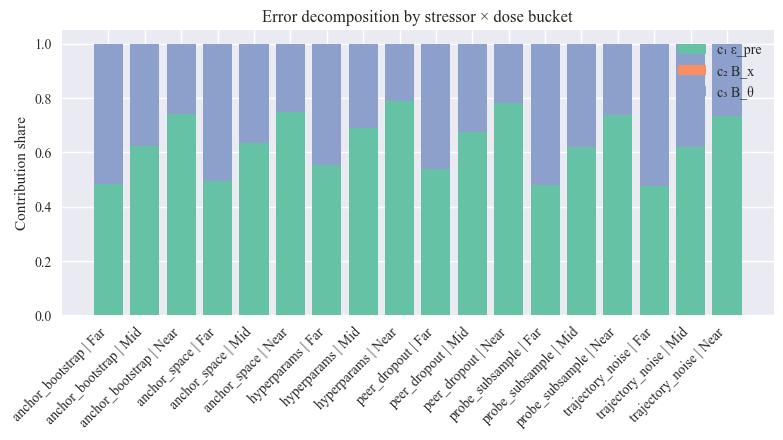

In [66]:
# --- Error decomposition by representative bucket (stressor × dose bucket) ---
contrib_cols = ['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']
coef_vec = model.coef_.ravel()

# Per-sample contributions
contrib_matrix = reg_df[contrib_cols].values * coef_vec
contrib_df = reg_df[['stressor', 'theta_bucket', 'lhs_abs']].copy()
contrib_df[['c1_eps', 'c2_Bx', 'c3_Btheta']] = contrib_matrix
contrib_df['total_contrib'] = contrib_df[['c1_eps', 'c2_Bx', 'c3_Btheta']].sum(axis=1)

# Choose representative groups (mean over combinations)
group_cols = ['stressor', 'theta_bucket']
rep_df = (
    contrib_df.groupby(group_cols)[['c1_eps', 'c2_Bx', 'c3_Btheta', 'total_contrib']]
    .mean()
    .reset_index()
)
rep_df['c1_share'] = rep_df['c1_eps'] / rep_df['total_contrib']
rep_df['c2_share'] = rep_df['c2_Bx'] / rep_df['total_contrib']
rep_df['c3_share'] = rep_df['c3_Btheta'] / rep_df['total_contrib']
rep_df = rep_df.sort_values(['stressor', 'theta_bucket'])

print('Representative error decomposition:')
print(rep_df[['stressor', 'theta_bucket', 'c1_share', 'c2_share', 'c3_share']].to_markdown(index=False))

# Plot stacked bars
colors = sns.color_palette('Set2', 3)
fig, ax = plt.subplots(figsize=(8, 4.5))
x_labels = rep_df[['stressor', 'theta_bucket']].agg(' | '.join, axis=1)
bottom = np.zeros(len(rep_df))
for share, label, color in zip(
    ['c1_share', 'c2_share', 'c3_share'],
    ['c₁ ε_pre', 'c₂ B_x', 'c₃ B_θ'],
    colors
):
    ax.bar(x_labels, rep_df[share], bottom=bottom, label=label, color=color)
    bottom += rep_df[share].values

ax.set_ylabel('Contribution share')
ax.set_title('Error decomposition by stressor × dose bucket')
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


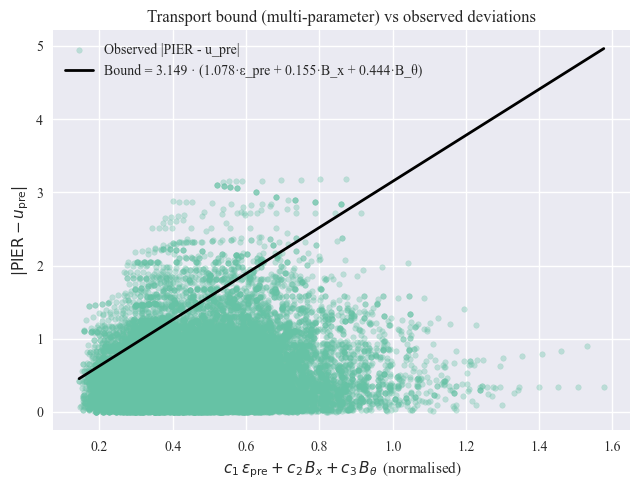

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Features for multi-parameter bound
X = transport_df[['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']].to_numpy()
Y = transport_df['lhs_abs'].to_numpy()

# Fit nonnegative linear RHS: c1*ε_pre + c2*B_x + c3*B_θ (no intercept per inequality)
lin = LinearRegression(positive=True, fit_intercept=False)
lin.fit(X, Y)
coef = lin.coef_.ravel()            # [c1, c2, c3]
rhs_lin = X @ coef                  # linear RHS per sample

# Calibrate a coverage multiplier k so that ~95% of points satisfy LHS ≤ k · RHS_lin
ratio = Y / np.clip(rhs_lin, 1e-6, None)
k95 = np.quantile(ratio, 0.95)
bound_vals = k95 * rhs_lin

# Plot: observed vs linear RHS, with the calibrated bound line
order = np.argsort(rhs_lin)
rhs_sorted = rhs_lin[order]
bound_sorted = bound_vals[order]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(rhs_lin, Y, s=16, alpha=0.35, label='Observed |PIER - u_pre|')
ax.plot(rhs_sorted, bound_sorted, color='black', linewidth=2,
        label=(f'Bound = {k95:.3f} · ('
               f'{coef[0]:.3f}·ε_pre + {coef[1]:.3f}·B_x + {coef[2]:.3f}·B_θ)'))

ax.set_xlabel(r'$\,c_1\,\varepsilon_{\mathrm{pre}} + c_2\,B_x + c_3\,B_\theta\,$ (normalised)')
ax.set_ylabel(r'$|\mathrm{PIER}-u_{\mathrm{pre}}|$')
ax.set_title('Transport bound (multi-parameter) vs observed deviations')
ax.legend()
plt.tight_layout()
plt.show()


In [71]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ---------------- 1) LHS vs. anchor–radius quartiles ----------------
radius_df = transport_df.copy()
radius_df['radius_quartile'] = pd.qcut(
    radius_df['anchor_radius_norm'], q=4,
    labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'],
    duplicates='drop'
)

radius_table = (
    radius_df.groupby('radius_quartile')['lhs_abs']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_lhs', 'std': 'std_lhs', 'count': 'n'})
    .reset_index()
)
print('LHS vs. anchor-radius quartiles')
print(radius_table.to_markdown(index=False))
# print(radius_table.to_latex(index=False))


# ---------------- 2) LHS vs. dose buckets --------------------------
dose_table = (
    transport_df.groupby('theta_bucket')['lhs_abs']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_lhs', 'std': 'std_lhs', 'count': 'n'})
    .reindex(['Near', 'Mid', 'Far'])
    .reset_index()
)
print('\nLHS vs. dose buckets')
print(dose_table.to_markdown(index=False))
# print(dose_table.to_latex(index=False))


# ---------------- 3) Multi-parameter bound calibration -------------
# Fit nonnegative linear model: LHS ≈ c1*ε_pre + c2*B_x + c3*B_θ (no intercept)
features = ['epsilon_norm', 'anchor_radius_norm', 'theta_gap_norm']
X_all = transport_df[features].to_numpy()
y_all = transport_df['lhs_abs'].to_numpy()

lin = LinearRegression(positive=True, fit_intercept=False)
lin.fit(X_all, y_all)
coef_vec = lin.coef_.ravel()     # [c1, c2, c3]
rhs_lin = X_all @ coef_vec       # linear RHS per sample
r2 = lin.score(X_all, y_all)

# Calibrate coverage multiplier k (95th percentile of y / rhs_lin)
ratio = y_all / np.clip(rhs_lin, 1e-6, None)
k95 = float(np.quantile(ratio, 0.95))
compliance = float(np.mean(y_all <= k95 * rhs_lin) * 100.0)

bound_table = pd.DataFrame(
    {
        'metric': [
            'k (95th percentile of LHS / (c1ε + c2Bx + c3Bθ))',
            'Compliance (% with LHS ≤ k·(c1ε + c2Bx + c3Bθ))',
            'c1 (ε_pre)', 'c2 (B_x)', 'c3 (B_θ)', 'R^2 (fit)'
        ],
        'value': [k95, compliance, coef_vec[0], coef_vec[1], coef_vec[2], r2],
    }
)
print('\nMulti-parameter bound summary')
print(bound_table.to_markdown(index=False))
# print(bound_table.to_latex(index=False))


# ---------------- 4) Error decomposition (mean contribution share) --
mean_features = transport_df[features].mean().to_numpy()
contrib = coef_vec * mean_features
total = contrib.sum() if contrib.sum() > 0 else 1.0

decomp_table = pd.DataFrame(
    {
        'component': ['ε_pre', 'B_x', 'B_θ'],
        'coefficient': coef_vec,
        'mean_feature': mean_features,
        'mean_contribution': contrib,
        'share_pct': 100.0 * contrib / total,
    }
)
print('\nError decomposition (mean contribution share)')
print(decomp_table.to_markdown(index=False))
# print(decomp_table.to_latex(index=False))


LHS vs. anchor-radius quartiles
| radius_quartile   |   mean_lhs |   std_lhs |    n |
|:------------------|-----------:|----------:|-----:|
| Q1 (smallest)     |   0.607466 |  0.537695 | 8100 |
| Q2                |   0.425552 |  0.334275 | 8109 |
| Q3                |   0.4907   |  0.34832  | 8100 |
| Q4 (largest)      |   0.551677 |  0.422315 | 8091 |

LHS vs. dose buckets
| theta_bucket   |   mean_lhs |   std_lhs |     n |
|:---------------|-----------:|----------:|------:|
| Near           |   0.498358 |  0.404928 | 10800 |
| Mid            |   0.51322  |  0.417241 | 10800 |
| Far            |   0.544863 |  0.447182 | 10800 |

Multi-parameter bound summary
| metric                                           |      value |
|:-------------------------------------------------|-----------:|
| k (95th percentile of LHS / (c1ε + c2Bx + c3Bθ)) |  3.14929   |
| Compliance (% with LHS ≤ k·(c1ε + c2Bx + c3Bθ))  | 95.0031    |
| c1 (ε_pre)                                       |  1.07758   |
|

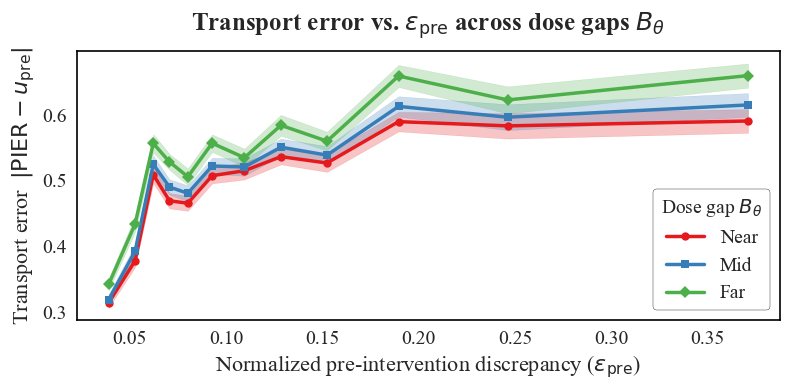

In [108]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'

df = transport_df[['epsilon_norm', 'theta_bucket', 'lhs_abs']].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df['theta_bucket'] = pd.Categorical(
    df['theta_bucket'], categories=['Near', 'Mid', 'Far'], ordered=True
)

# Bin epsilon
NBINS = 12
df['eps_bin'] = pd.qcut(df['epsilon_norm'], q=NBINS, duplicates='drop')
summ = (
    df.groupby(['theta_bucket', 'eps_bin'])
    .agg(
        eps_mid=('epsilon_norm', 'median'),
        mean_lhs=('lhs_abs', 'mean'),
        sem_lhs=('lhs_abs', lambda s: s.std(ddof=1) / np.sqrt(len(s))),
        n=('lhs_abs', 'size'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

palette = sns.color_palette('Set1', n_colors=df['theta_bucket'].nunique())
markers = ['o', 's', 'D']  # one marker style per bucket

for (bucket, sub), color, marker in zip(summ.groupby('theta_bucket'), palette, markers):
    sub = sub.sort_values('eps_mid')

    # Error bands first (behind line)
    ax.fill_between(
        sub['eps_mid'],
        sub['mean_lhs'] - sub['sem_lhs'],
        sub['mean_lhs'] + sub['sem_lhs'],
        color=color, alpha=0.25, zorder=1
    )

    # Line + markers on top
    ax.plot(
        sub['eps_mid'], sub['mean_lhs'],
        color=color, linewidth=2.5, label=bucket,
        alpha=1.0, zorder=2,
        marker=marker, markersize=6, markeredgecolor='black'
    )

# === Styling ===
ax.set_xlabel(r'Normalized pre-intervention discrepancy ($\varepsilon_{\mathrm{pre}}$)', fontsize=16)
ax.set_ylabel(r'Transport error  $|\mathrm{PIER}-u_{\mathrm{pre}}|$', fontsize=16)
ax.set_title(r'Transport error vs. $\varepsilon_{\mathrm{pre}}$ across dose gaps $B_\theta$',
             fontsize=18, fontweight='bold', pad=15)

ax.tick_params(axis='both', labelsize=14)
ax.grid(False)

# Frame (spines visible and black)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

# Legend styled consistently
ax.legend(title='Dose gap $B_\\theta$',
          fontsize=14, title_fontsize=14,
          frameon=True, framealpha=0.9, edgecolor='black',
          loc='lower right')

plt.tight_layout()
plt.show()




In [125]:
import numpy as np
import pandas as pd

# Prepare data (same inputs as the plot)
df = transport_df[['epsilon_norm', 'theta_bucket', 'lhs_abs']].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df['theta_bucket'] = pd.Categorical(df['theta_bucket'], categories=['Near', 'Mid', 'Far'], ordered=True)

# Bin epsilon
NBINS = 12
df['eps_bin'] = pd.qcut(df['epsilon_norm'], q=NBINS, duplicates='drop')

# Summarize per (bucket, eps_bin)
summ = (
    df.groupby(['theta_bucket', 'eps_bin'])
    .agg(
        eps_mid=('epsilon_norm', 'median'),
        mean_lhs=('lhs_abs', 'mean'),
        sem_lhs=('lhs_abs', lambda s: s.std(ddof=1) / np.sqrt(len(s))),
        n=('lhs_abs', 'size'),
    )
    .reset_index()
)

# Format cell as "mean ± SEM (n)"
def fmt_row(r):
    mean = f"{r['mean_lhs']:.3f}"
    sem = "-" if pd.isna(r['sem_lhs']) else f"{r['sem_lhs']:.3f}"
    return f"{mean} ± {sem} (n={int(r['n'])})"

summ['eps_mid'] = summ['eps_mid'].astype(float)
summ['eps_mid_round'] = summ['eps_mid'].round(3)
summ['cell'] = summ.apply(fmt_row, axis=1)

# Pivot to wide table: rows = εpre bin midpoints, columns = dose buckets
table = (
    summ.pivot(index='eps_mid_round', columns='theta_bucket', values='cell')
    .sort_index()
)

# Optional: rename columns for paper
table.columns.name = 'Dose bucket (Bθ)'
table.index.name = 'ε_pre (bin center, normalized)'

print(table.to_markdown())
# table.to_latex(escape=False)  # uncomment to export LaTeX


|   ε_pre (bin center, normalized) | Near                  | Mid                   | Far                   |
|---------------------------------:|:----------------------|:----------------------|:----------------------|
|                            0.039 | 0.314 ± 0.008 (n=900) | 0.319 ± 0.008 (n=900) | 0.342 ± 0.009 (n=900) |
|                            0.053 | 0.378 ± 0.009 (n=912) | 0.393 ± 0.010 (n=912) | 0.434 ± 0.012 (n=912) |
|                            0.062 | 0.509 ± 0.013 (n=888) | 0.525 ± 0.013 (n=888) | 0.556 ± 0.014 (n=888) |
|                            0.071 | 0.469 ± 0.012 (n=900) | 0.490 ± 0.012 (n=900) | 0.528 ± 0.012 (n=900) |
|                            0.08  | 0.465 ± 0.011 (n=900) | 0.480 ± 0.012 (n=900) | 0.506 ± 0.013 (n=900) |
|                            0.093 | 0.507 ± 0.012 (n=909) | 0.522 ± 0.012 (n=909) | 0.556 ± 0.013 (n=909) |
|                            0.109 | 0.515 ± 0.013 (n=891) | 0.520 ± 0.013 (n=891) | 0.534 ± 0.014 (n=891) |
|                  

In [77]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Prepare input
df = transport_df[['epsilon_norm', 'theta_bucket', 'lhs_abs']].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df['theta_bucket'] = pd.Categorical(df['theta_bucket'], categories=['Near', 'Mid', 'Far'], ordered=True)

# ---------------- A) Correlation and slope per dose bucket ----------------
rows = []
for bucket, sub in df.groupby('theta_bucket'):
    if len(sub) < 3:
        rows.append({'theta_bucket': bucket, 'n': len(sub),
                     'pearson_r': np.nan, 'spearman_r': np.nan, 'slope_dlhs_deps': np.nan})
        continue
    x = sub['epsilon_norm'].to_numpy()
    y = sub['lhs_abs'].to_numpy()
    # Pearson
    pearson_r = np.corrcoef(x, y)[0, 1] if np.std(x) > 0 and np.std(y) > 0 else np.nan
    # Spearman
    try:
        spearman_r = spearmanr(x, y, nan_policy='omit').statistic
    except Exception:
        spearman_r = np.nan
    # Simple linear slope d(lhs)/d(eps)
    slope = np.polyfit(x, y, 1)[0] if np.std(x) > 0 else np.nan
    rows.append({'theta_bucket': bucket, 'n': len(sub),
                 'pearson_r': pearson_r, 'spearman_r': spearman_r, 'slope_dlhs_deps': slope})

trend_table = pd.DataFrame(rows)
print('Trend per dose bucket (ε_pre → |PIER - u_pre|):')
print(trend_table.to_markdown(index=False))
# print(trend_table.to_latex(index=False))

# ----------- B) Mean |PIER - u_pre| by ε_pre quantile bins and bucket -----------
NBINS = 8  # adjust to taste
df['eps_bin'] = pd.qcut(df['epsilon_norm'], q=NBINS, duplicates='drop')
# Bin centers for nice column ordering/labels
bin_centers = df.groupby('eps_bin')['epsilon_norm'].median().sort_values()
summary_bins = (
    df.groupby(['theta_bucket', 'eps_bin'])['lhs_abs']
    .agg(mean_lhs='mean', std_lhs='std', n='size')
    .reset_index()
)
summary_bins['eps_mid'] = summary_bins['eps_bin'].map(bin_centers.to_dict())

# Pivot mean table: rows=buckets, cols=ε bin centers
mean_pivot = summary_bins.pivot(index='theta_bucket', columns='eps_mid', values='mean_lhs')
mean_pivot = mean_pivot.sort_index(axis=1)
mean_pivot.index.name = 'dose_bucket'
mean_pivot.columns = [f'{c:.2f}' for c in mean_pivot.columns]
print('\nMean |PIER - u_pre| across ε_pre bins (columns) by dose bucket (rows)')
print(mean_pivot.to_markdown())
# print(mean_pivot.to_latex())

# Optional: counts by bin (to show support)
count_pivot = summary_bins.pivot(index='theta_bucket', columns='eps_mid', values='n').sort_index(axis=1)
count_pivot.index.name = 'dose_bucket'
count_pivot.columns = [f'{c:.2f}' for c in count_pivot.columns]
print('\nCounts per ε_pre bin (support for each mean)')
print(count_pivot.to_markdown())
# print(count_pivot.to_latex())

# ----------- C) Low-vs-high ε_pre contrast per bucket (simple, readable) ---------
low_q, high_q = 0.20, 0.80
rows = []
for bucket, sub in df.groupby('theta_bucket'):
    q_low = sub['epsilon_norm'].quantile(low_q)
    q_high = sub['epsilon_norm'].quantile(high_q)
    low_mask = sub['epsilon_norm'] <= q_low
    high_mask = sub['epsilon_norm'] >= q_high
    low_mean = sub.loc[low_mask, 'lhs_abs'].mean()
    high_mean = sub.loc[high_mask, 'lhs_abs'].mean()
    rows.append({
        'theta_bucket': bucket,
        f'mean_lhs (ε ≤ {low_q:.0%} q)': low_mean,
        f'mean_lhs (ε ≥ {high_q:.0%} q)': high_mean,
        'delta (high - low)': high_mean - low_mean,
        'n_low': int(low_mask.sum()),
        'n_high': int(high_mask.sum()),
        'n_total': int(len(sub)),
    })
contrast_table = pd.DataFrame(rows)
print('\nLow vs High ε_pre contrast by dose bucket')
print(contrast_table.to_markdown(index=False))
# print(contrast_table.to_latex(index=False))

# ----------- D) Combined monotonicity summary (coarse check) -----------
# For each bucket, check if mean LHS increases monotonically across ε bins (by centers)
mono_rows = []
for bucket, sub in summary_bins.groupby('theta_bucket'):
    sub = sub.sort_values('eps_mid')
    diffs = np.diff(sub['mean_lhs'].to_numpy())
    frac_nonneg = np.mean(diffs >= -1e-12) if len(diffs) > 0 else np.nan
    mono_rows.append({'theta_bucket': bucket, 'bins': len(sub), 'frac_nonneg_diffs': frac_nonneg})
mono_table = pd.DataFrame(mono_rows)
print('\nMonotonicity (fraction of successive ε bins where mean LHS does not decrease)')
print(mono_table.to_markdown(index=False))
# print(mono_table.to_latex(index=False))


Trend per dose bucket (ε_pre → |PIER - u_pre|):
| theta_bucket   |     n |   pearson_r |   spearman_r |   slope_dlhs_deps |
|:---------------|------:|------------:|-------------:|------------------:|
| Near           | 10800 |    0.133206 |          nan |          0.517708 |
| Mid            | 10800 |    0.133341 |          nan |          0.533992 |
| Far            | 10800 |    0.127734 |          nan |          0.548246 |

Mean |PIER - u_pre| across ε_pre bins (columns) by dose bucket (rows)
| dose_bucket   |     0.04 |     0.06 |     0.07 |     0.09 |     0.11 |     0.15 |     0.20 |     0.32 |
|:--------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| Near          | 0.325883 | 0.473752 | 0.460304 | 0.500862 | 0.527262 | 0.524298 | 0.591648 | 0.583178 |
| Mid           | 0.335031 | 0.487878 | 0.477658 | 0.517262 | 0.535155 | 0.537766 | 0.616183 | 0.599118 |
| Far           | 0.36288  | 0.52431  | 0.511435 | 0.548744 | 0.553635 | 0.56